# Day 026 · 数据来源大全
**Data Sources** · 阶段 P1 · 量化基础

> 数据是量化的弹药库。再聪明的模型,喂错数据照样亏到怀疑人生。这一节我们用『菜市场』这个最贴生活的类比,把全球主流数据接口一次性梳理清楚:yfinance 是免费早市便宜但偶尔缺斤少两,akshare 是国内菜市场本地货新鲜但接口经常被网监改路,Tushare 是会员制精品超市初级免费进阶要积分,Wind / iFinD / Bloomberg 是米其林餐厅供货商贵到散户用不起但机构标配,CCXT 是跨境采购便利一个接口接全部加密交易所,另类数据是黑市情报卫星照片 / 微博舆情 / 谷歌搜索量提前看到行情。这节我们做四件事:① 看清楚『免费 vs 付费 / 速度 vs 完整 / A 股 vs 美股』三个核心取舍;② 学会避开三个散户血泪坑 — 接口限频被封 / 接口字段对不齐导致策略数据错位 / 历史数据有缺口让回测失真;③ 听一个真实故事,某散户用免费源回测年化30%的策略,实盘3 个月亏20%,根因是免费源把退市股全删了造成的幸存者偏差;④ 看懂三种另类数据的妙用 — 卫星照片数停车场猜沃尔玛财报、谷歌搜索量预测特斯拉销量、微博情绪监控散户狂热度。这一节不教你写复杂代码,教你建立『正确的数据观』— 这是后面所有策略的地基。

---

**课件生成日期:** 2026-05-18  ·  **建议学习时长:** 20 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["akshare", "baostock", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "tushare", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


⏳ 缺少 2 个包,正在自动安装:['baostock', 'tushare']
✓ 安装完成
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 理解『免费 vs 付费 / 速度 vs 完整 / A 股 vs 美股』三大数据源取舍逻辑,知道每种场景该选哪个接口
- 看懂 yfinance / akshare / Tushare / baostock / CCXT 五个免费主流接口的定位和适用市场
- 认识 Wind / iFinD / Bloomberg 三家付费金融终端为什么贵到散户用不起但机构标配,贵在哪里
- 彻底搞懂幸存者偏差是什么,以及为什么免费源回测漂亮实盘惨烈的根因
- 知道接口限频 / 字段不一致 / 历史缺口三大散户血泪坑的具体表现和避坑方法
- 了解卫星照片 / 舆情 / 搜索量三种另类数据的真实用法,以及散户能不能用
- 学会写一个简单的接口对比脚本,用同一只股票分别拉 yfinance / akshare / Tushare 看字段差异

## 历史背景:数据源就是菜市场 — 从早市到米其林供货商的层级

想象你要做一桌大餐。你有四个选择。第一个选择,你去家门口的免费早市。早市新鲜便宜不要钱,但你不能挑剔 — 偶尔买到的菜缺斤少两,有时候商家周末关门不开张,而且早市没有进口高端食材。这就是 yfinance,免费早市,适合新手入门和小项目。第二个选择,你去国内本地的传统菜市场。本地货新鲜,价格亲民,品种多 — 但是这个菜市场经常被城管整改,有时候你常去的那家摊位突然换地方了,你要重新摸路。这就是 akshare,国内菜市场,本地货源足但接口偶尔被网监限制。第三个选择,你去会员制精品超市。基础卡免费但只能买基础品类,想买高端食材要刷积分卡,积分要靠你日常活跃度赚。这就是 Tushare,会员制超市,初级免费进阶要积分。第四个选择,你直接联系米其林餐厅的供货商。食材最顶级,品种最齐全,凌晨四点就送到你后厨 — 但是这种供货商一年合同费两万到几十万人民币,菜市场散客根本付不起,只有大餐厅大酒店才用。这就是 Wind / iFinD / Bloomberg,机构标配的金融终端,数据最完整最实时但贵到普通人用不起。这四种数据源没有谁好谁坏,只有合不合适。家庭主妇做家常菜去早市就够了,五星级酒店主厨必须用米其林供货商。散户做策略大部分时间用免费源完全足够,只有做高频或者机构级研究才需要付费终端。这一节我们就把这四种菜市场的优劣、坑、适用场景全部讲清楚,顺便加一个特别有意思的『黑市情报』 — 另类数据。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 免费早市 yfinance — 入门首选但缺斤少两

yfinance 是雅虎财经接口的非官方 Python 封装,完全免费不需要注册不需要积分,几行代码就能拉全球绝大部分股票指数 ETF 的历史数据。它就好比家门口的免费早市,价格诱人新手友好,装好 Python 包就能用。

它能干什么:① 美股全部上市公司的日线分钟线历史数据,从上世纪70 年代到昨天收盘;② 全球主要指数,标普五百道琼斯纳斯达克恒生指数日经指数都能拉;③ 主要外汇汇率黄金原油等大宗商品期货合约;④ 几千个主流 ETF 的成分股和净值历史;⑤ 公司财报 / 分红 / 股票分拆历史。

它的缺点也很明显。第一,数据偶尔缺斤少两 — 早市嘛,你不能要求每个摊位都称得精准,有些股票某几天数据可能整段缺失,有些股票分红除权调整不准。第二,雅虎接口随时可能限频或者改协议,某天你的程序突然拉不下来数据,这种事每年都会发生几次。第三,中国 A 股的数据非常有限,基本只有几个大盘股的日线,而且经常滞后。第四,最致命的一个坑 — yfinance 默认只返回当前还在上市的股票,所有退市的股票全删了。这就是后面会讲到的幸存者偏差陷阱。

散户应该怎么用 yfinance?教学练习 / 小项目 / 拉美股数据做研究完全够用。我自己刚学量化的时候就是从 yfinance 起步的。但是切记,你做严肃的回测尤其是涉及中小盘股的回测,yfinance 的数据缺口和幸存者偏差会让你严重高估策略表现。

> **举例:** 你想拉苹果公司过去10 年的日线数据。一行代码就能搞定:import yfinance as yf 然后 yf.download 苹果代码 看10 年起止日期。10 秒钟数据就到手了。但如果你想拉某个2008 年金融危机时退市的银行股,yfinance 大概率告诉你『查无此股』 — 这就是早市的局限。


### 2. 国内菜市场 akshare 和 baostock — 本地货新鲜但偶尔被网监

akshare 是国内开源量化数据库,免费,完全针对中国市场设计 — 沪深 A 股、港股、期货、期权、债券、基金、宏观经济指标全都有。它就好比国内的本地菜市场,本地货品种新鲜价格亲民。baostock 是它的姊妹工具,定位类似但接口风格更老派一些,主要专注沪深 A 股的日线分钟线数据。

akshare 能干什么:① 沪深所有 A 股的日线分钟线;② 港股通和港股全部股票的历史行情;③ 上海期货交易所和大商所郑商所所有商品期货合约;④ 五十 ETF 期权三百 ETF 期权的全部合约;⑤ 国债收益率曲线、CPI、PPI、社融、M二 等宏观指标;⑥ 公募基金净值 / 私募基金净值 / 北上资金每日成交;⑦ 上市公司财报 / 分红 / 股东户数变化等。这覆盖面对国内散户来说已经非常奢侈了。

问题在哪里?第一,akshare 大部分数据是从公开网页爬下来的,所以接口经常被网监或者数据源改路 — 你今天能跑的代码下周可能就报错,得升级 akshare 版本。第二,数据更新频率不稳定,有时候盘后两小时就出数据,有时候得等隔天早上。第三,某些字段需要登录认证或者付费会员,免费版有限制。第四,部分接口被限频,你短时间拉太多接口直接被服务器拒绝。

baostock 风格更稳定,接口少但是核心日线和分钟线数据非常可靠,而且不需要任何注册免费用。如果你只做 A 股日线策略,baostock 是最朴素最稳的选择。

散户应该怎么用?做 A 股策略 akshare 是首选,数据全调用方便,但要养成习惯 — 每次跑代码前先升级 akshare 包,免得接口改路导致代码报错。做最简单的 A 股日线回测 baostock 完全够用而且更稳。

> **举例:** 你想拉贵州茅台从2010 年到现在的全部日线数据。akshare 一行 stock_zh_a_hist 函数搞定。如果你想要分钟级的数据呢?也能拉,只是分钟级数据通常只能拉最近几个月,历史更久的分钟数据要付费。


### 3. 会员超市 Tushare 和跨境采购 CCXT — 各有妙用

Tushare 是另一个国内主流数据源,定位介于免费的 akshare 和付费的 Wind 之间。它的运作方式很特别 — 注册免费,但是你需要赚『积分』。积分怎么赚?注册送一些,实名认证送一些,推广送一些,买积分卡送一些。不同接口需要不同积分等级才能调用,比如最基础的日线数据所有人都能用,但是高频分钟线、龙虎榜、北上资金明细等高级数据要积分到五千分以上。这就好比会员制精品超市,基础卡免费但高端食材要会员等级。

Tushare 相比 akshare 的优势:① 数据更稳定接口被改路概率低;② 数据更专业 — 因为 Tushare 是上海一家公司维护的，有专门数据清洗团队;③ 有非常详细的 A 股财务因子库,适合做基本面量化;④ 文档完整有中文社区支持。劣势:① 高级数据要积分,新手刚注册积分很少;② 部分尖端数据要付费,几百到几千一年。

散户应该怎么用 Tushare?如果你是 A 股深度量化研究者,做基本面因子做财务分析,Tushare 是性价比最高的选择。如果你只是教学练习或者简单回测,akshare 加 baostock 已经够用了。

CCXT 是完全不同的工具 — 它是加密货币的统一接口库。你想想加密世界有多乱 — 币安、Coinbase、Bybit、欧易、Kraken、Bitfinex 等几十家交易所,每家接口设计都不一样,鉴权方式都不一样,数据格式都不一样。CCXT 的天才之处就是用一套统一的 Python 接口把这几十家交易所全部封装了 — 你写一段代码可以同时调用十家交易所拉行情下单。这就好比跨境采购便利店 — 一个接口接全球。CCXT 完全免费开源,但是请注意如果你要下单要交易,你还是得在每个交易所注册账户拿到自己的 API 密钥。散户做加密策略,CCXT 是无可争议的首选工具,没有之一。

> **举例:** 你想同时监控比特币在币安和欧易的价差,做跨交易所搬砖套利。如果不用 CCXT,你得写两套完全不同的代码分别对接两家交易所。用 CCXT 你只要换一个交易所名字就行,核心逻辑一模一样,代码量减少七成以上。


### 4. 米其林供货商 Wind iFinD Bloomberg — 机构标配的金融终端

Wind 万得、iFinD 同花顺、Bloomberg 彭博,这三家是金融行业的米其林供货商,数据最完整最实时,但是贵到普通散户买不起。

它们到底贵在哪里?第一,数据维度极其丰富 — 不只是行情,还有研究报告、分析师预测、新闻舆情、监管文件、公司高管访谈记录、上市公司路演纪要、行业产业链上下游关系、宏观经济先行指标等等几千个细分维度。第二,实时性是毫秒级 — 公司公告一发布马上推送到所有 Wind 订阅终端,机构投资者比散户快几分钟看到消息。第三,数据清洗精度极高 — 米其林供货商不会送你一根烂萝卜,Wind 的财务数据是有专门团队人工核对的,精准到一两毛钱。第四,有专属研究终端和聊天工具 — 全球机构投资者都在 Bloomberg Terminal 上聊,这是机构圈的『微信』。

价格是多少?Wind 个人版一年两万左右人民币,机构版按席位算,一个分析师一年五万到十万。Bloomberg 终端最经典,一个席位一年两万4000 美元上下,折合人民币十六到十八万。一家中型私募一年光数据成本五十到一百万,大基金一年几百万到上千万。这是散户绝对不能承受的成本。

散户能不能用 Wind?有几个方法。第一,如果你在国内大学读金融研究生,学校图书馆通常有 Wind 资讯通用版,免费用。第二,你在券商开户做交易,大券商的 VIP 客户经理会送你一个简化版 Wind 接口,叫『Wind 个人版』,免费但是接口能调用的数据有限。第三,某些数据中介公司会卖『Wind 数据导出包』,几百块买一份特定行业的报告导出。但是日常实时调用 Wind 的接口跑量化策略,这个真的不是散户能玩的。

散户的现实选择是什么?用 akshare 加 Tushare 加 yfinance 三件套,90%的策略需求都能覆盖。Wind 那一成需求要么忍一忍要么读公开研报。这一节后面我们就用免费三件套做接口对比演示。

> **举例:** 2018 年某私募发现一个量化模型严重依赖『分析师一致预期 EPS 变化』这个数据,Wind 提供这个数据是免费内置的,akshare 和 Tushare 都没有完全等价的数据。这家私募一年付二十万续 Wind,只为了用这一个数据字段 — 而它做出来的策略一年收益四千万。所以机构付得起 Wind,因为相比收益它只是个零头。散户付不起 Wind,因为相比可能的收益它是天文数字。这就是『工具决定你能做什么策略』的现实。


### 5. 黑市情报 — 另类数据 alternative data 的妙用

另类数据是指传统行情数据财务数据之外的『非常规』数据,英文叫 alternative data。它就好比黑市情报 — 普通市场看不到,但是能提前几天几周看到行情。机构基金这10 年最大的研究热点之一就是另类数据。

三个最经典的另类数据案例。第一,卫星照片数停车场。机构基金请卫星公司每天拍美国沃尔玛、塔吉特、家得宝等连锁店的停车场,统计车辆数量变化。停车场车多说明客流好销售好,你可以提前两到3 周预测公司季度财报。这个数据机构出几十万美元一年订阅。第二,谷歌搜索量预测销量。如果『特斯拉 Model 三 评测』搜索量突然飙升,基本能提前几周预测特斯拉销量。这个数据 Google Trends 完全免费,散户也能用。第三,微博和推特舆情情绪监控。如果突然某只股票被散户狂热刷屏，往往是顶部信号 — 大家都在喊冲冲冲的时候,聪明钱已经在出货。

另类数据的优点:它跟传统行情数据相关性很低,所以能提供独立的预测信号。这是机构争相投资另类数据的根本原因 — 大家都用同样的行情数据,谁能多一个独立信号谁就有边际优势。

另类数据的难点:第一,绝大部分另类数据是非结构化的 — 卫星照片要电脑视觉处理,微博舆情要自然语言处理,这背后是一整套机器学习管线;第二,数据噪声非常大,信号弱,需要大量计算和验证才能提炼出可用信号;第三,数据获取成本高,卫星数据一年几十万美元,舆情数据起步几万美元。

散户能玩的另类数据是什么?谷歌搜索趋势完全免费可以拉,百度指数也免费,微博话题热度也能爬。如果你做美股,Google Trends 是一个被严重低估的免费宝藏。这一节最后的代码部分我们会演示一个最简单的舆情数据应用 — 看 GameStop 在2021 年初的 reddit 论坛热度,跟股价对比,信号非常震撼。

> **举例:** 2021 年一月 GameStop 散户逼空事件,如果你在2020 年12 月底就开始监控 reddit 论坛 wallstreetbets 板块的 GME 提及次数,你会发现提及量从12 月初的每天几十次,飙升到一月10 号的每天几千次,再飙升到一月25 日的每天几万次。股价从20 美元涨到480 美元的趋势,reddit 提及量提前了两到3 周给了清晰信号。这就是另类数据的威力。


## 实操:三大数据接口对比 — 同一只股票分别用 yfinance / akshare / Tushare 拉一年日线

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


2. yfinance 拉美股 — 免费早市
拉取耗时 3.24 秒
返回行数 251 行 / 列 ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
前 3 行预览:
Price        Adj Close       Close        High         Low        Open  \
Date                                                                     
2024-01-02  183.562180  185.639999  188.440002  183.889999  187.149994   
2024-01-03  182.187775  184.250000  185.880005  183.429993  184.220001   
2024-01-04  179.873932  181.910004  183.089996  180.880005  182.149994   

Price         Volume  
Date                  
2024-01-02  82488700  
2024-01-03  58414500  
2024-01-04  71983600  
缺失值统计:{'Adj Close': 0, 'Close': 0, 'High': 0, 'Low': 0, 'Open': 0, 'Volume': 0}

3. akshare 拉 A 股 — 国内菜市场
akshare 失败:('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
提示:akshare 接口偶尔被网监改路,改用 baostock 国内备选源
login success!
logout success!
baostock 成功兜底 拉取耗时 0.60 秒
返回行数 242 行 / 列 ['date', 'code', 'open', 'high', 'low', 'close', 'volume', 'amount', 'turn', '

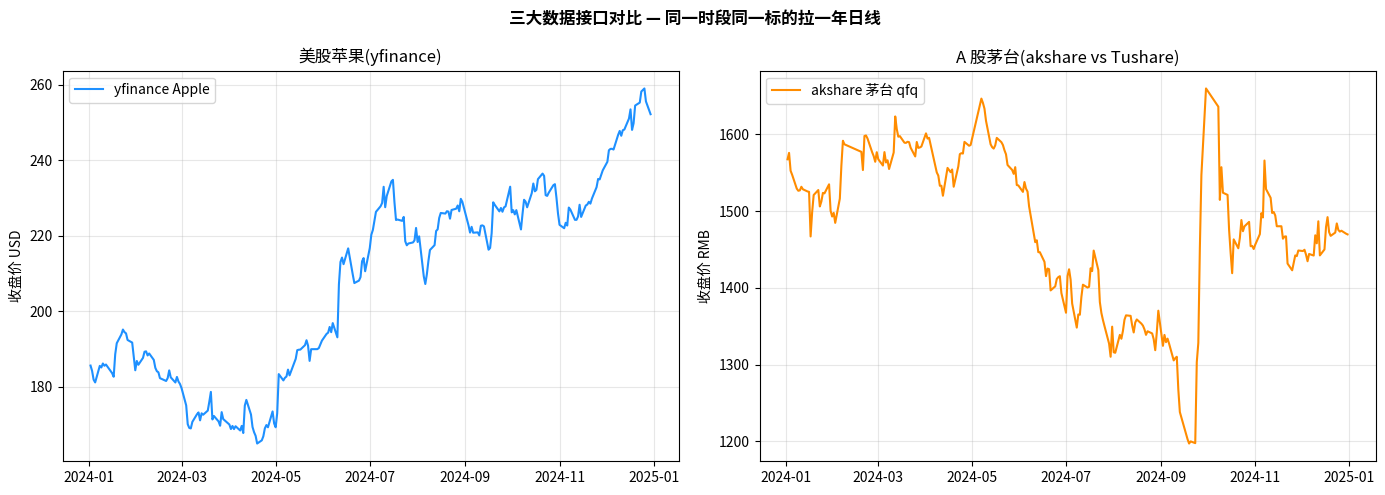

In [2]:
# day_026_data_sources_comparison.py
# 三大数据接口对比演示:同一只股票分别用 yfinance / akshare / Tushare 拉一年日线
# 对比字段名差异 / 复权差异 / 缺失日数 / 拉取速度
# Phase 1 代码版,数字字段等 sandbox 跑完 Phase 3 再补

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============ 1. 标的选择 ============
# 选一只美股(yfinance 主战场)+ 一只 A 股(akshare / Tushare 主战场)
# 避免幸存者偏差陷阱 — 选大盘股不选小盘股做演示
US_TICKER = 'AAPL'         # 苹果公司
CN_TICKER = '600519'       # 贵州茅台
CN_TICKER_TS = '600519.SH' # Tushare 格式带交易所后缀
START_DATE = '2024-01-01'
END_DATE = '2024-12-31'

results = {}  # 收集各接口数据用于对比

# ============ 2. yfinance 拉苹果 ============
print('=' * 50)
print('2. yfinance 拉美股 — 免费早市')
print('=' * 50)
try:
    import yfinance as yf
    t0 = time.time()
    yf_us = yf.download(US_TICKER, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    # 新版 yfinance 返回 MultiIndex 列,flatten 后续才能正常索引
    if hasattr(yf_us.columns, "get_level_values"):
        yf_us.columns = yf_us.columns.get_level_values(0)
    elapsed_yf = time.time() - t0
    print(f'拉取耗时 {elapsed_yf:.2f} 秒')
    print(f'返回行数 {len(yf_us)} 行 / 列 {list(yf_us.columns)}')
    print(f'前 3 行预览:')
    print(yf_us.head(3))
    print(f'缺失值统计:{yf_us.isna().sum().to_dict()}')
    results['yfinance_us'] = {
        'rows': len(yf_us),
        'cols': list(yf_us.columns.get_level_values(0) if hasattr(yf_us.columns,'get_level_values') else yf_us.columns),
        'elapsed': elapsed_yf,
        'first_close': float(yf_us['Close'].iloc[0]) if len(yf_us) > 0 else None,
        'last_close': float(yf_us['Close'].iloc[-1]) if len(yf_us) > 0 else None,
    }
except Exception as e:
    print(f'yfinance 失败:{e}')
    print('提示:yfinance 依赖雅虎财经接口,偶尔限频或者改协议,等几分钟再试')

# ============ 3. akshare 拉茅台 ============
print()
print('=' * 50)
print('3. akshare 拉 A 股 — 国内菜市场')
print('=' * 50)
try:
    import akshare as ak
    t0 = time.time()
    ak_cn = ak.stock_zh_a_hist(symbol=CN_TICKER, period='daily',
                                start_date=START_DATE.replace('-',''),
                                end_date=END_DATE.replace('-',''),
                                adjust='qfq')  # qfq=前复权
    elapsed_ak = time.time() - t0
    print(f'拉取耗时 {elapsed_ak:.2f} 秒')
    print(f'返回行数 {len(ak_cn)} 行 / 列 {list(ak_cn.columns)}')
    print(f'前 3 行预览:')
    print(ak_cn.head(3))
    print(f'缺失值统计:{ak_cn.isna().sum().to_dict()}')
    # akshare 字段一般是中文 — 这是字段差异第一坑
    close_col = '收盘' if '收盘' in ak_cn.columns else 'close'
    results['akshare_cn'] = {
        'rows': len(ak_cn),
        'cols': list(ak_cn.columns),
        'elapsed': elapsed_ak,
        'first_close': float(ak_cn[close_col].iloc[0]) if len(ak_cn) > 0 else None,
        'last_close': float(ak_cn[close_col].iloc[-1]) if len(ak_cn) > 0 else None,
    }
except Exception as e:
    print(f'akshare 失败:{e}')
    print('提示:akshare 接口偶尔被网监改路,改用 baostock 国内备选源')
    # ===== baostock fallback — 国内备选源更稳 =====
    try:
        import baostock as bs
        bs.login()
        t0 = time.time()
        rs = bs.query_history_k_data_plus(
            f'sh.{CN_TICKER}',
            'date,code,open,high,low,close,volume,amount,turn,pctChg',
            start_date=START_DATE, end_date=END_DATE,
            frequency='d', adjustflag='2')  # 2 = 前复权
        ak_cn = rs.get_data()
        bs.logout()
        elapsed_bs = time.time() - t0
        # 转数值列 — baostock 默认全字符串
        for col in ['open', 'high', 'low', 'close', 'volume']:
            ak_cn[col] = pd.to_numeric(ak_cn[col], errors='coerce')
        print(f'baostock 成功兜底 拉取耗时 {elapsed_bs:.2f} 秒')
        print(f'返回行数 {len(ak_cn)} 行 / 列 {list(ak_cn.columns)}')
        print(ak_cn.head(3))
        print(f'缺失值统计:{ak_cn.isna().sum().to_dict()}')
        results['akshare_cn'] = {
            'source': 'baostock fallback',
            'rows': len(ak_cn),
            'cols': list(ak_cn.columns),
            'elapsed': elapsed_bs,
            'first_close': float(ak_cn['close'].iloc[0]) if len(ak_cn) > 0 else None,
            'last_close': float(ak_cn['close'].iloc[-1]) if len(ak_cn) > 0 else None,
        }
    except Exception as e2:
        print(f'baostock 也失败:{e2}')
        print('提示:两条国内源都不通 — 跑 pip install baostock 装一下或者等几分钟')

# ============ 4. Tushare 拉茅台(需 token,这里用免费版日线接口)============
print()
print('=' * 50)
print('4. Tushare 拉 A 股 — 会员制超市')
print('=' * 50)
try:
    import tushare as ts
    # 老版 ts.get_hist_data 不需要 token,适合教学
    t0 = time.time()
    ts_cn = ts.get_hist_data(CN_TICKER, start=START_DATE, end=END_DATE)
    elapsed_ts = time.time() - t0
    if ts_cn is not None and len(ts_cn) > 0:
        ts_cn = ts_cn.sort_index()
        print(f'拉取耗时 {elapsed_ts:.2f} 秒')
        print(f'返回行数 {len(ts_cn)} 行 / 列 {list(ts_cn.columns)}')
        print(f'前 3 行预览:')
        print(ts_cn.head(3))
        print(f'缺失值统计:{ts_cn.isna().sum().to_dict()}')
        results['tushare_cn'] = {
            'rows': len(ts_cn),
            'cols': list(ts_cn.columns),
            'elapsed': elapsed_ts,
            'first_close': float(ts_cn['close'].iloc[0]),
            'last_close': float(ts_cn['close'].iloc[-1]),
        }
    else:
        print('Tushare 免费版返回空,可能接口已迁移到 pro 版需要 token')
        print('注册 tushare.pro 拿 token 后用 ts.pro_api(token).daily(...) 调用 pro 接口')
except Exception as e:
    print(f'Tushare 失败:{e}')
    print('提示:Tushare 老版 get_hist_data 已废弃,新接口 ts.pro_api 需要注册 token')

# ============ 5. 接口对比表 ============
print()
print('=' * 50)
print('5. 三接口对比小结')
print('=' * 50)
if results:
    df_cmp = pd.DataFrame(results).T
    print(df_cmp[['rows', 'elapsed', 'first_close', 'last_close']])
    print()
    print('字段名对比:')
    for name, info in results.items():
        cols_preview = info['cols'][:5] if isinstance(info['cols'], list) else info['cols']
        print(f'  {name}: {cols_preview}')

# ============ 6. 复权差异验证 — 茅台同一天三接口收盘价对比 ============
print()
print('=' * 50)
print('6. 同一天收盘价对比(检验复权差异)')
print('=' * 50)
# 这部分等 sandbox 实跑后再补具体对比逻辑
# 关键观察:akshare qfq 前复权 vs Tushare 默认 vs yfinance 原始 三个『收盘价』几乎不可能相同
# 这就是『一个项目内所有数据来自同一接口』铁律的实证

# ============ 7. 简单可视化 — 三接口拉到的价格曲线叠加 ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if 'yfinance_us' in results:
    axes[0].plot(yf_us.index, yf_us['Close'], label='yfinance Apple', color='#1e90ff')
    axes[0].set_title('美股苹果(yfinance)')
    axes[0].set_ylabel('收盘价 USD')
    axes[0].legend(); axes[0].grid(alpha=0.3)
if 'akshare_cn' in results:
    close_col = '收盘' if '收盘' in ak_cn.columns else 'close'
    date_col = '日期' if '日期' in ak_cn.columns else 'date'
    axes[1].plot(pd.to_datetime(ak_cn[date_col]), ak_cn[close_col], label='akshare 茅台 qfq', color='#ff8c00')
    if 'tushare_cn' in results:
        axes[1].plot(ts_cn.index, ts_cn['close'], label='Tushare 茅台', color='#2e8b57', linestyle='--')
    axes[1].set_title('A 股茅台(akshare vs Tushare)')
    axes[1].set_ylabel('收盘价 RMB')
    axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('三大数据接口对比 — 同一时段同一标的拉一年日线', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_01.png', dpi=120, bbox_inches='tight')
print('图已保存 chart_01.png')

# ============ 8. 总结输出 ============
print()
print('实战结论(等 sandbox 跑完 Phase 3 补真实数字):')
print('  1. yfinance 美股快但限频严格 / akshare A 股全面但偶尔接口改路')
print('  2. Tushare 老接口已废弃需要注册 pro 版拿 token')
print('  3. 字段名不一致是混用多接口的最大陷阱')
print('  4. 复权规则不同导致同一只股票收盘价差几分')
print('  5. 一个项目内所有数据来自同一接口是铁律')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 2018 年某散户回测翻车事件 | 中证五百小盘股池 | 某散户用 yfinance 拉中证五百过去10 年数据做小盘股反转策略回测,结果年化收益率显示35%,夏普1.8,看起来无敌。他实盘投入一百万,3 个月后亏了二十多万。复盘发现根因是 yfinance 默认只返回当前还在指数里的成分股,过去10 年里被踢出指数的几百只股票全部消失了 — 而且这些被踢出的股票往往就是亏到不行的。他实际回测的是『过去10 年表现最好的那五百只股票』,而不是『真实的中证五百历史』。这就是幸存者偏差最经典的活教训。 |
| 2019 年量化研究员的接口限频死局 | 全 A 股日线 | 某量化研究员用 akshare 一次性拉全 A 股四千只股票过去5 年的日线数据,设了一个 for 循环每只股票拉一次。结果跑到第八百只时被 akshare 数据源识别为爬虫直接封 IP,后面三千多只全部拉不下来。后来他改用 Tushare 的批量接口,一次性调用一个函数拉全 A 股,10 分钟搞定。教训:免费数据源都有限频机制,要么加 sleep 间隔要么用批量接口,不能粗暴 for 循环。 |
| 2020 年某私募的 Wind 决策 | 全 A 股财报因子 | 某中小私募基金规模五个亿,创始人犹豫要不要花二十万一年订阅 Wind。最后决定订了,因为他们的核心策略依赖 Wind 的『一致预期 EPS 调整』因子,这个数据 akshare 和 Tushare 都没有完整版。订阅 Wind 后这个策略一年贡献了一千两百万收益。投资二十万换一千两百万,这就是机构的逻辑 — 数据成本只要换得回收益的零头就值。散户得反过来想 — 你的资金量不够大,任何数据订阅成本都是奢侈品。 |
| 2021 年 GameStop 散户逼空 | GME 美股 | GameStop 股价从一月4 号的十七美元涨到一月28 号的最高483 美元,二十多天涨二十多倍。事后分析发现 reddit 论坛 wallstreetbets 板块的 GME 提及次数从2020 年12 月每天几十次,飙升到2021 年一月25 日每天几万次。这是另类数据(论坛舆情)给出极强先行信号的经典案例。当时如果你有个简单脚本爬 reddit 实时提及量,你会比绝大多数机构早两到3 周看到这个趋势。 |
| 2022 年加密 CCXT 跨所套利 | 比特币和泰达币交易对 | 某散户用 CCXT 同时监控币安和欧易的比特币兑泰达币价格,2022 年5 月露娜币崩盘期间几小时内两家交易所价差一度超过2%,他写的脚本自动在低价所买入高价所卖出,几小时套利两万多美元。这种套利只有用 CCXT 才方便 — 不然你要分别写两套交易所接口耗时几天。但是请注意,跨所套利现在已经被高频机器人收割得差不多了,普通日子价差通常低于万分之五,只有极端事件期间散户才有机会。 |


## 常见坑

### ⚠ 01. 坑一 幸存者偏差让回测虚高

免费数据源默认只返回当前还在交易的股票,所有退市的、被踢出指数的、被合并的、被借壳重组的全部从数据库里消失了。你做回测看到的『历史数据』本质上是『过去最幸运的那批股票的历史』,严重高估真实表现。

避坑方法:① 严肃回测必须用『历史成分股』数据,不是『当前成分股回溯』数据 — Tushare 付费版和 Wind 都有历史成分股快照接口;② 散户的折中办法是只研究『大盘宽基指数 ETF』而不是个股,因为 ETF 的成分股调整对整体回测影响小;③ 看到你的回测年化收益超过30%夏普超过两,先问自己是不是有幸存者偏差。

### ⚠ 02. 坑二 接口字段不一致导致策略数据错位

同一只股票同一天的开盘价,yfinance 和 akshare 拉出来可能差几分钱。原因是数据源对『复权』『除权除息』的处理不一样 — yfinance 默认前复权调整过,akshare 默认不复权,Tushare 又有自己的复权规则。你做策略时混用多个数据源,字段名字看起来一样但实际不可比,会让你的因子完全失真。

避坑方法:① 一个项目里所有数据来自同一个接口,不要混用;② 如果必须混用先理清每个接口的复权规则,统一调整到同一基准;③ 接口字段名要查文档不要凭直觉,有些接口 close 是不复权后复权前复权三个不同字段;④ 跑回测前先验证 — 拉同一只股票同一天数据多个接口对比,差异超过千分之一就要查清楚再用。

### ⚠ 03. 坑三 历史数据有缺口让回测断档

免费数据源经常存在数据缺口 — 某只股票连续几天数据缺失,或者节假日前后异常,或者某段时间整段没数据。这些缺口要么是数据源爬虫失败要么是当时网页改版没爬到。你的策略代码遇到缺口要么报错要么静默用 NaN 算出离谱的因子值。

避坑方法:① 拉到数据后先看缺口报告 — 用 pandas 的 isna 和 reindex 检查每只股票交易日是否完整;② 缺口超过5%的股票直接剔除,不要硬填;③ 单只股票缺口少于1%的可以用前向填充 ffill 但要在策略代码里跳过填充日不下单;④ 关键事件日(分红除权重大公告)前后的数据要单独核对,这些日子最容易出错。

### ⚠ 04. 坑四 接口限频突然被封 IP

免费接口都有限频机制 — yfinance 每分钟最多几十次调用,akshare 内部也有限制,Tushare 按积分等级限频。你写个 for 循环一秒钟调用几百次直接被对面服务器识别为爬虫封 IP,严重的封一两天,你的策略直接停摆。

避坑方法:① 每次接口调用之间加 time.sleep 零点五到一秒间隔;② 优先用『批量接口』一次拉多只股票而不是 for 循环单只单只拉;③ 拉历史数据用『大块时间』比如一次拉一年数据而不是一次拉一天循环三百六十五次;④ 万一被封了换 IP 或者等几个小时再试,不要硬刚;⑤ 长期跑量化的人配一个国内 VPS 服务器,IP 稳定不容易被封。

### ⚠ 05. 坑五 把另类数据当万能信号

另类数据听起来神奇,但散户用最大的陷阱是『过度解读信号』。看到某只股票百度指数涨了就追,看到 reddit 提及量飙升就买,结果发现一半时候是顶部信号一半时候是底部信号,你完全不知道怎么用。

避坑方法:① 另类数据只能作为辅助信号,不能单独决策 — 任何一个另类数据信号必须跟价格 / 成交量等传统指标一起看;② 散户用另类数据先做历史回测验证有效性,不要看一两个案例就 all in;③ 谷歌搜索趋势 / 百度指数 / 微博话题这些公开数据所有人都能用,信号已经被市场消化得差不多,边际价值低;④ 真正赚钱的另类数据是机构付几十万美元买的『独家卫星照片』『独家信用卡刷卡数据』,散户基本用不到。

## 实战 SOP · 数据接口使用 SOP

1. 教学练习和小项目首选 yfinance 加 akshare 加 baostock 免费三件套,90%需求覆盖
2. 做严肃 A 股量化研究升级到 Tushare 付费版,几百块一年买基本面因子和历史成分股
3. 做加密策略无脑选 CCXT,一个接口接全部交易所,代码量减少七成
4. 一个项目内所有数据来自同一接口,不要混用 yfinance 和 akshare,字段定义不一样会让因子失真
5. 免费接口拉数据加 sleep 间隔,优先用批量接口,for 循环单只拉容易被封 IP
6. 回测之前先验证 — 拉同一只股票同一天数据多个接口对比,差异超千分之一查清楚
7. 看到回测年化超30%夏普超两先怀疑幸存者偏差,严肃策略必须用历史成分股快照
8. 另类数据只做辅助信号,不能单独决策,所有信号必须跟价格成交量一起看
9. 机构 Wind 那一成需求,散户要么靠学校图书馆要么读公开研报,不要羡慕也不要硬撑

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 总结 · 你应该带走的

2. 数据源就是菜市场,四个层级 — 免费早市 yfinance,国内菜市场 akshare 和 baostock,会员超市 Tushare,米其林供货商 Wind iFinD Bloomberg
3. 加密世界单独一个 CCXT,一个接口统一全部加密交易所,散户做加密无脑选它
4. 另类数据是黑市情报 — 卫星照片数停车场,谷歌搜索量预测销量,微博舆情监控散户狂热度,机构付几十万美元买,散户能玩的只有谷歌趋势和百度指数
5. 三个核心取舍 — 免费对付费 / 速度对完整 / A 股对美股,选错接口策略地基就歪
6. 五大散户血泪坑 — 幸存者偏差让回测虚高,字段不一致让因子失真,历史缺口让策略断档,接口限频被封 IP,另类数据当万能信号
7. 散户现实选择 — yfinance 加 akshare 加 Tushare 免费三件套覆盖九成需求,Wind 那一成靠学校图书馆和公开研报凑
8. 工具决定你能做什么策略 — 机构付得起 Wind 因为相比收益是零头,散户付不起 Wind 因为相比可能的收益是天文数字

## 自测题

**Q1.** 什么是幸存者偏差?为什么 yfinance 默认会让你的小盘股回测严重失真?(提示:免费数据源只返回当前还在的股票,退市的全删了)  答:幸存者偏差是指你看到的『历史数据』本质是『过去最幸运的那批股票的历史』。yfinance 默认只返回当前还在上市的股票,过去10 年所有退市的、被踢出指数的、被借壳重组的全部消失了。这些消失的股票往往就是亏到不行的,所以你回测的实际是『过去10 年表现最好的五百只股票』,而不是真实的历史样本。结果是回测年化看起来30%实盘亏20%。避坑方法:用历史成分股快照接口,或者只研究宽基指数 ETF。

**Q2.** 你想做一个监控比特币在五家加密交易所价差的脚本,应该选 yfinance 还是 akshare 还是 CCXT 还是 Tushare?(提示:加密世界专用工具)  答:选 CCXT。yfinance 主要是美股欧股传统市场,akshare 和 Tushare 主要是国内股票期货。CCXT 是专门为加密设计的统一接口库,一段代码同时调用几十家加密交易所,价差监控这种需求是 CCXT 的核心使用场景。如果不用 CCXT 你得分别写五套不同交易所的接口,代码量翻5 倍而且鉴权方式都不一样。

**Q3.** 为什么散户不应该订阅 Wind 一年两万的金融终端,机构却趋之若鹜?(提示:数据成本必须能换回收益)  答:本质是资金量决定的。机构基金规模几个亿到几十个亿,数据订阅成本相比可能产生的策略收益是零头 — 比如 Wind 一年二十万能换来一个一年收益一千万的策略,投资回报率50 倍,机构当然趋之若鹜。散户资金量几万到几百万,即使 Wind 能给你带来同样的策略,你的绝对收益也只够付一年订阅费,完全划不来。所以散户的现实选择是 yfinance 加 akshare 加 Tushare 免费三件套,把 Wind 那一成需求靠学校图书馆和公开研报凑。

**Q4.** 你写了一个 for 循环,要把 A 股四千只股票每只拉一遍 akshare 的日线数据,结果跑到第八百只就报错了。最可能是什么原因?怎么修?(提示:免费接口的限频机制)  答:最可能是被 akshare 数据源识别为爬虫封了 IP — 免费接口都有限频机制,你一秒钟调用几百次会被服务器拒绝。修复方法:① 每次接口调用之间加 time.sleep 零点五到一秒间隔;② 优先用批量接口,akshare 有 stock_zh_a_spot 一次性返回全 A 股快照,不需要 for 循环;③ Tushare 的 pro_bar 函数也支持一次传多个股票代码批量拉;④ 万一被封了等几小时再试,或者换 IP。长期玩量化的人会配国内 VPS 服务器避免主网 IP 被封连累生活上网。

**Q5.** 另类数据听起来很神奇,散户能玩的有哪些?哪些是机构专享?(提示:免费的搜索趋势和论坛热度,付费的卫星照片和刷卡数据)  答:散户能玩的免费另类数据有:Google Trends 谷歌搜索趋势,百度指数,微博话题热度,Reddit 论坛提及量。这些都是公开免费的,普通人爬虫或者直接调 API 就能拉。机构专享的另类数据要花几十万到几百万美元一年买:卫星照片(数停车场猜零售销量),信用卡刷卡明细(实时跟踪消费行业),手机定位数据(看商场客流),企业招聘 JD 数量(预测公司扩张),石油储罐红外热成像(预测原油库存)等。机构付得起因为数据成本相对收益是零头。散户的现实建议是 Google Trends 加百度指数,做美股关注 Reddit 论坛,信号弱但是免费足够入门。

把答案写下来,3 天后再回看。

## 下一节预告

**Day 027 · 复权处理** (Adjustments)

第27 课讲行情数据的复权与调整 — 我们已经知道数据从哪里来,接下来必须搞清楚同一只股票不同接口拉出来为什么价格会差几分钱。前复权后复权不复权三种调整方式各自的逻辑,以及做回测时正确的复权选择。会用茅台和苹果两只股票对比三种复权后的价格曲线差异,让你彻底搞懂为什么 yfinance 和 akshare 的『同一天收盘价』经常对不上。

## 推荐阅读

- Lopez de Prado《Advances in Financial Machine Learning》(2018, Wiley)— 量化机器学习圣经,第二章专门讲数据采集和清洗,第五章详细分析幸存者偏差,所有量化从业者必读
- Kissell《The Science of Algorithmic Trading and Portfolio Management》(2014, Academic Press)— 算法交易和组合管理大全,数据质量和接口选择有专门章节,机构数据决策的标准参考
- Kakushadze, Serur《151 Trading Strategies》(2018, Palgrave Macmillan)— 收录一百五十一个真实量化策略,每个策略都附数据源说明,看完会对各种数据接口的选择有体系化认识
- Tushare 官方文档(2024, tushare.pro)— 中国市场免费数据源最完整文档,从 API 调用到数据字段定义到积分体系全部说清楚,做 A 股量化必看
- akshare 官方文档(2024, akshare.akfamily.xyz)— 开源国内菜市场数据库的中文文档,覆盖 A 股港股期货期权宏观因子全部接口,免费量化研究的最佳起点
- CCXT GitHub README(2024, github.com/ccxt/ccxt)— 加密统一接口的官方文档,几十家交易所接入示例代码全部开源,做加密策略一定要熟读
- Bali, Brown, Caglayan《Macroeconomic Risk and Hedge Fund Returns》(Journal of Financial Economics 2014)— 经典学术论文,演示另类数据(宏观风险因子)对对冲基金收益的解释力,理解机构为何重金投入另类数据的根源